In [5]:
import os
import random
from pathlib import Path
from collections import Counter
import json

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

from torchvision import transforms
from torchvision.models import vgg16, VGG16_Weights
from scipy.stats import chi2_contingency,fisher_exact
from tqdm import tqdm


# Table of Contents
[Table of Contents](#scrollTo=tO5Bf1cNtEBd)

>[VGG Cyclical](#scrollTo=pPmt25Qds_y3)

>>[Performance Monitoring](#scrollTo=f129f09d)

>[Gender Bias Analysis](#scrollTo=78UELuuxtZj-)
---

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# reproducibility
SEED = 1187
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
CHECKPOINT_PATH = Path("/content/drive/MyDrive/fer-project/fer2013_processed/vgg16_adults_long_best.pt")

# Load directly from JSON — no os.walk, no filename parsing
with open("/content/drive/MyDrive/fer-project/fer2013_processed/classified_files.json") as f:
    loaded_data = json.load(f)


records     = loaded_data["adult_records"]
image_files = [r["drive_path"] for r in records]
labels      = [r["emotion"]    for r in records]
genders     = [r["gender"]     for r in records]   # bonus: available for bias analysis

label_names  = sorted(set(labels))
label_to_idx = {label: i for i, label in enumerate(label_names)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

print("Classes:", label_names)
print("Total refined images:", len(image_files))

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total refined images: 25175


##VGG Cyclical

In [7]:
# train, val, test split
train_files, temp_files, train_labels, temp_labels = train_test_split(
    image_files,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED
)

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

Train: 20140
Val: 2517
Test: 2518


In [8]:
# transforms
imagenet_mean = VGG16_Weights.DEFAULT.transforms().mean
imagenet_std = VGG16_Weights.DEFAULT.transforms().std

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=5
    ),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])


In [9]:
# dataset class
class FERDataset(Dataset):
    def __init__(self, files, labels, transform=None):
        self.files = files
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("L")
        y = label_to_idx[self.labels[idx]]

        if self.transform:
            img = self.transform(img)

        return img, y


train_dataset = FERDataset(train_files, train_labels, train_transform)
val_dataset = FERDataset(val_files, val_labels, val_transform)
test_dataset = FERDataset(test_files, test_labels, val_transform)


loader_kwargs = dict(
    num_workers=2,
    pin_memory=True
) if torch.cuda.is_available() else {}

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    **loader_kwargs
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    **loader_kwargs
)


In [10]:
# Initialize model with all layers unfrozen
num_classes = len(label_names) if label_names else 7
model = vgg16(weights=VGG16_Weights.DEFAULT)

# Unfreeze every layer to allow the model to learn facial micro-expressions
for param in model.parameters():
    param.requires_grad = True

# Replace final classifier layer
model.classifier[6] = nn.Linear(
    model.classifier[6].in_features,
    num_classes
)

model = model.to(device)
print(f"Model initialized with {num_classes} classes. All layers are now trainable.")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:01<00:00, 356MB/s]


Model initialized with 7 classes. All layers are now trainable.


In [11]:
# class weighting
train_counts = Counter(train_labels)

class_counts = np.array(
    [train_counts[c] for c in label_names],
    dtype=np.float32
)

class_weights = class_counts.sum() / (
    len(class_counts) * class_counts
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)



In [12]:
# Updated Optimizer and Cyclical Scheduler for full fine-tuning
base_lr = 1e-6
max_lr = 1e-4

optimizer = optim.Adam(model.parameters(), lr=base_lr, weight_decay=1e-4)

# step_size_up defines half a cycle (2-8 times batches per epoch)
step_size_up = 4 * len(train_loader)

scheduler = optim.lr_scheduler.CyclicLR(
    optimizer,
    base_lr=base_lr,
    max_lr=max_lr,
    step_size_up=step_size_up,
    mode='triangular', # Restarts from high to low periodically
    cycle_momentum=False
)

In [13]:
# train and evaluation functions
def train_one_epoch():
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in tqdm(train_loader, leave=False):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_true = [], []

    with torch.no_grad():
        for x, y in tqdm(loader, leave=False):
            x, y = x.to(device), y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(y.cpu().numpy())

    return total_loss / total, correct / total, all_true, all_preds

In [14]:
# Final training loop with persistent History Tracking
NUM_EPOCHS = 25
best_val_acc = best_val_acc if 'best_val_acc' in globals() else 0


if 'history' not in globals() or not history.get('train_loss'):
    history = {
        'lr': [],
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        # Record LR before stepping the scheduler
        current_lr = scheduler.get_last_lr()[0]
        history['lr'].append(current_lr)

        # CyclicLR step happens after every batch
        scheduler.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    train_loss = total_loss / total
    val_loss, val_acc, _, _ = evaluate(val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Last LR: {current_lr:.6f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print("Saved best model.")

Epoch 1/25 | Train Acc: 0.2854 | Val Acc: 0.4672 | Last LR: 0.000026
Saved best model.


Epoch 2/25 | Train Acc: 0.4837 | Val Acc: 0.5217 | Last LR: 0.000050
Saved best model.


Epoch 3/25 | Train Acc: 0.5410 | Val Acc: 0.5610 | Last LR: 0.000075
Saved best model.


Epoch 4/25 | Train Acc: 0.5592 | Val Acc: 0.6063 | Last LR: 0.000100
Saved best model.


Epoch 5/25 | Train Acc: 0.5888 | Val Acc: 0.6099 | Last LR: 0.000075
Saved best model.


...

Epoch 21/25 | Train Acc: 0.7341 | Val Acc: 0.6794 | Last LR: 0.000075


Epoch 22/25 | Train Acc: 0.7854 | Val Acc: 0.6782 | Last LR: 0.000051


Epoch 23/25 | Train Acc: 0.8173 | Val Acc: 0.6921 | Last LR: 0.000026


Epoch 24/25 | Train Acc: 0.8531 | Val Acc: 0.7008 | Last LR: 0.000001
Saved best model.


Epoch 25/25 | Train Acc: 0.8677 | Val Acc: 0.6909 | Last LR: 0.000026


### Performance Monitoring
To evaluate the effectiveness of the CyclicLR, we need to track the learning rate at every step and the loss/accuracy at every epoch. We evaluate the model using metrics such as accuracy, confusion matrix, and per-class F1 scores.

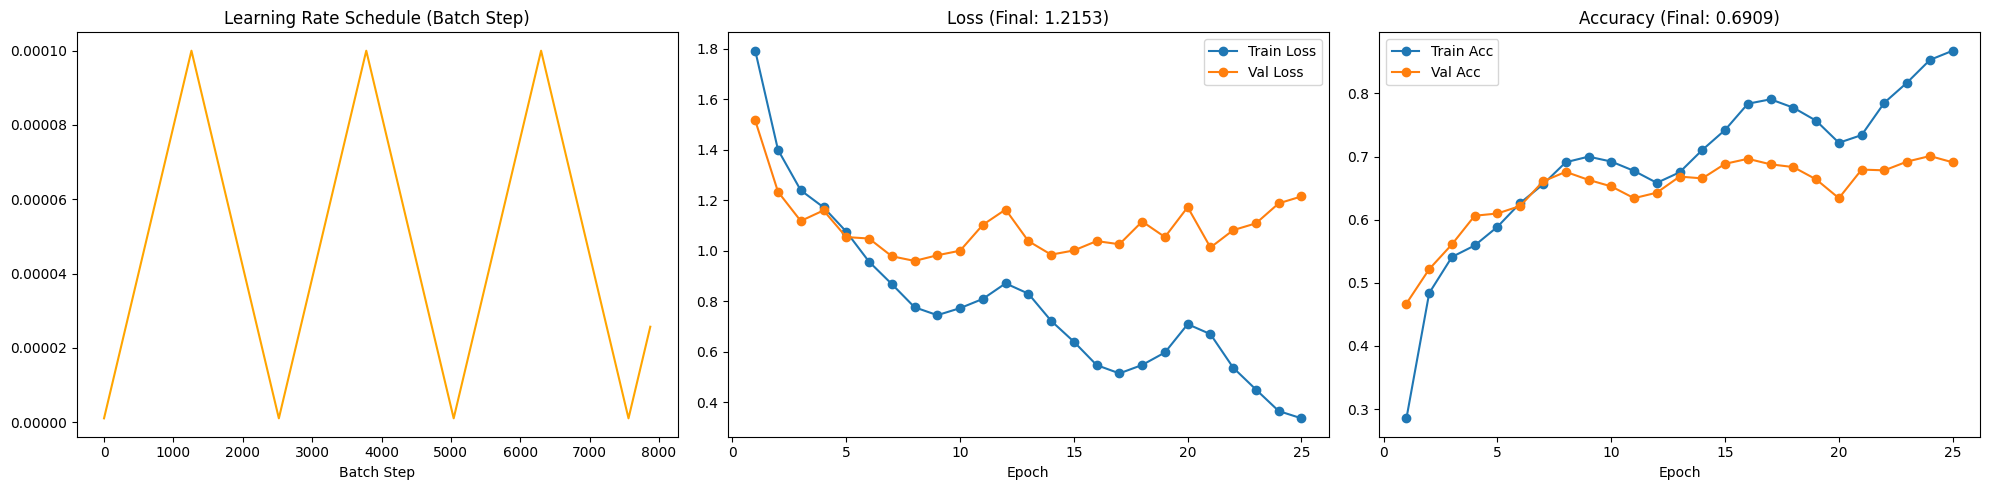

In [15]:
# Final robust visualization pulling from history
def plot_final_results(history_dict):
    import matplotlib.pyplot as plt


    t_loss = history_dict.get('train_loss', [])
    v_loss = history_dict.get('val_loss', [])
    t_acc = history_dict.get('train_acc', [])
    v_acc = history_dict.get('val_acc', [])
    lrs = history_dict.get('lr', [])


    if not t_loss and 'train_loss' in globals():
        t_loss, v_loss = [train_loss], [val_loss]
        t_acc, v_acc = [train_acc], [val_acc]
        print("Note: Full epoch history was reset. Plotting the most recent epoch found in memory.")

    if not t_loss and not lrs:
        print("No training data found. Please run the training loop for at least one epoch.")
        return

    fig, axs = plt.subplots(1, 3, figsize=(20, 5))

    # 1. Learning Rate (Batch Level)
    if lrs:
        axs[0].plot(lrs, color='orange')
        axs[0].set_title('Learning Rate Schedule (Batch Step)')
        axs[0].set_xlabel('Batch Step')

    # 2. Loss (Epoch Level)
    if t_loss:
        epochs = range(1, len(t_loss) + 1)
        axs[1].plot(epochs, t_loss, label='Train Loss', marker='o')
        axs[1].plot(epochs, v_loss, label='Val Loss', marker='o')
        axs[1].set_title(f'Loss (Final: {v_loss[-1]:.4f})')
        axs[1].set_xlabel('Epoch')
        axs[1].legend()

    # 3. Accuracy (Epoch Level)
    if t_acc:
        epochs = range(1, len(t_acc) + 1)
        axs[2].plot(epochs, t_acc, label='Train Acc', marker='o')
        axs[2].plot(epochs, v_acc, label='Val Acc', marker='o')
        axs[2].set_title(f'Accuracy (Final: {v_acc[-1]:.4f})')
        axs[2].set_xlabel('Epoch')
        axs[2].legend()

    plt.tight_layout()
    plt.show()

plot_final_results(history)

In [16]:
# load best model + test evaluation
model.load_state_dict(torch.load(CHECKPOINT_PATH))

test_loss, test_acc, all_true, all_preds = evaluate(test_loader)

print("\nFINAL TEST RESULTS")
print("Test Accuracy:", test_acc)

macro_f1 = f1_score(all_true, all_preds, average="macro")
weighted_f1 = f1_score(all_true, all_preds, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

print(classification_report(
    all_true,
    all_preds,
    target_names=label_names,
    digits=3
))



FINAL TEST RESULTS
Test Accuracy: 0.7013502779984114
Macro F1: 0.6950601875749257
Weighted F1: 0.6992255116117674
              precision    recall  f1-score   support

       angry      0.619     0.619     0.619       365
     disgust      0.783     0.783     0.783        46
        fear      0.565     0.536     0.550       373
       happy      0.865     0.889     0.877       665
     neutral      0.669     0.700     0.684       444
         sad      0.618     0.563     0.589       405
    surprise      0.737     0.791     0.763       220

    accuracy                          0.701      2518
   macro avg      0.694     0.697     0.695      2518
weighted avg      0.698     0.701     0.699      2518



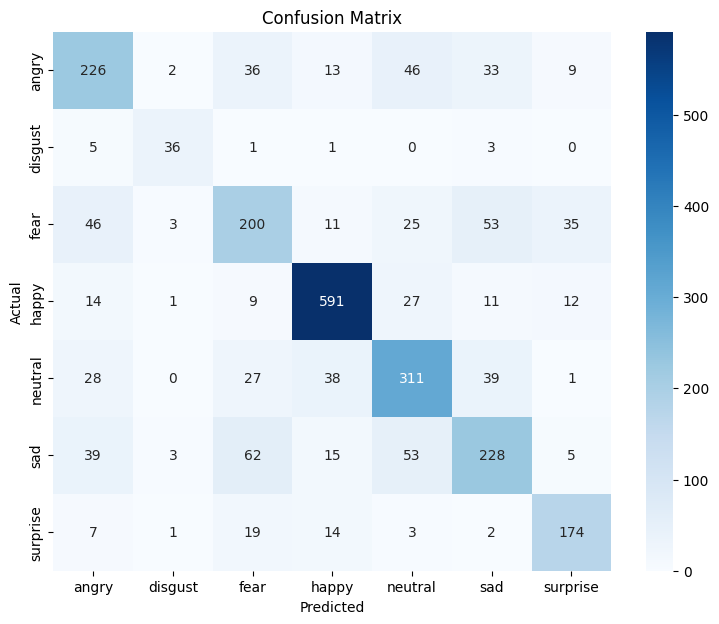

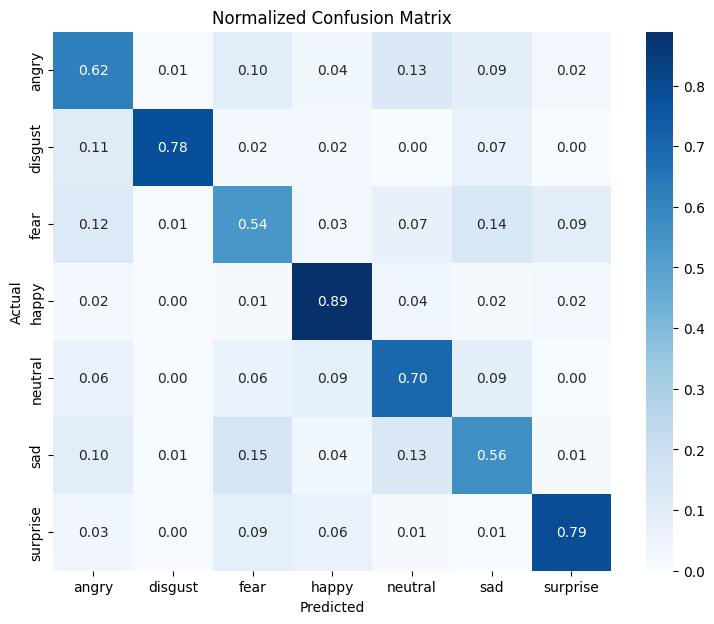

In [17]:
# confusion matrices
cm = confusion_matrix(all_true, all_preds)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names,
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=label_names,
    yticklabels=label_names,
    cmap="Blues"
)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

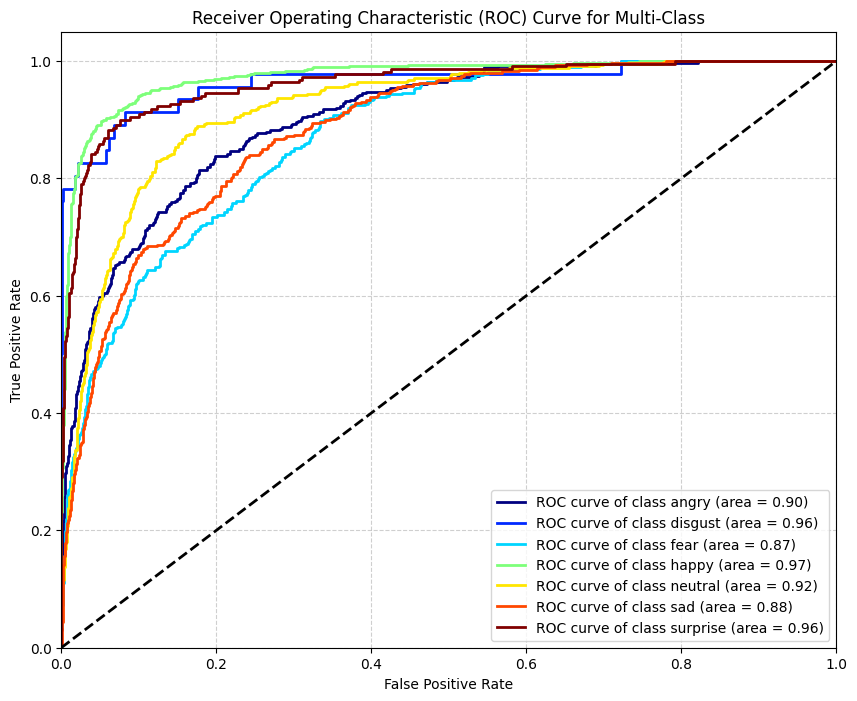

In [18]:


# Get probabilities for test set
def predict_proba(loader):
    model.eval()
    all_probs, all_true = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, leave=False, desc="Predicting probabilities"):
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_true.extend(y.cpu().numpy())
    return np.array(all_probs), np.array(all_true)

all_probs, all_true_probs = predict_proba(test_loader)

# Binarize the true labels for ROC curve calculation
n_classes = len(label_names)
all_true_binarized = label_binarize(all_true_probs, classes=range(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(all_true_binarized[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.jet(np.linspace(0, 1, n_classes))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(label_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-Class')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Gender Bias Analysis

In [19]:
# === Load checkpoint ===
# Edit this path to wherever your trained checkpoint lives.
CHECKPOINT_PATH = "/content/drive/MyDrive/fer2013_processed/vgg16_adults_long_best.pt"
BIAS_RESULTS_CSV     = "/content/drive/MyDrive/fer2013_processed/vgg_bias_results.csv"

BATCH_SIZE = 64
# Rebuild the architecture (must match training-side cell 9).
# weights=None skips the imagenet download since we're loading our own weights.
model = vgg16(weights=None)

# Plain nn.Linear -- this is what the checkpoint was actually saved with
model.classifier[6] = nn.Linear(model.classifier[6].in_features, len(label_names))

model = model.to(device)
state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()
print(f'Loaded: {CHECKPOINT_PATH}')


Loaded: /content/drive/MyDrive/fer2013_processed/vgg16_adults_long_best.pt


In [20]:
# === Bias dataset + forward pass ===

class BiasTestDataset(Dataset):
    """Returns (image, emotion_idx, gender_str). Mirrors val_transform pipeline."""

    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform  = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        # RGB (3-channel) to match the training pipeline. VGG needs 3 channels.
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        gender  = os.path.basename(os.path.dirname(path))   # "male_adult" / "female_adult"
        emotion = os.path.basename(path).split("_")[0]
        return img, label_to_idx[emotion], gender


bias_test_dataset = BiasTestDataset(test_files, transform=val_transform)
bias_test_loader  = DataLoader(
    bias_test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs
)


def evaluate_bias(model, loader):
    model.eval()
    rows = []
    with torch.no_grad():
        for x, y_emotion, genders in tqdm(loader, desc="Forward pass"):
            x = x.to(device, non_blocking=True)
            probs = F.softmax(model(x), dim=1)
            confs, preds = probs.max(dim=1)
            for t, p, c, g in zip(y_emotion.numpy(), preds.cpu().numpy(),
                                  confs.cpu().numpy(), genders):
                rows.append((int(t), int(p), float(c), g))
    df = pd.DataFrame(rows, columns=["true_idx", "pred_idx", "confidence", "gender"])
    df["true_emotion"] = df["true_idx"].map(idx_to_label)
    df["pred_emotion"] = df["pred_idx"].map(idx_to_label)
    df["is_correct"]   = df["true_emotion"] == df["pred_emotion"]
    return df


df_results = evaluate_bias(model, bias_test_loader)
df_results.to_csv(BIAS_RESULTS_CSV, index=False)
print(f"\nSaved {len(df_results)} predictions -> {BIAS_RESULTS_CSV}")
print("\nTest set gender distribution:")
print(df_results["gender"].value_counts())
print(f"\nOverall test accuracy: {df_results['is_correct'].mean():.4f}")


Forward pass: 100%|██████████| 40/40 [00:02<00:00, 19.41it/s]



Saved 2518 predictions -> /content/drive/MyDrive/fer2013_processed/vgg_bias_results.csv

Test set gender distribution:
gender
female_adult    1344
male_adult      1174
Name: count, dtype: int64

Overall test accuracy: 0.8594


### Analysis 1: Overall accuracy bias

Does overall accuracy differ between male and female faces? Reports per-class
F1 per gender, Wilson 95% CIs on overall accuracy, and a chi-square test on
the accuracy gap (p < 0.05 means the gap is unlikely to be noise).


In [21]:

print("Analysis 1: Overall accuracy bias")


genders = sorted(df_results["gender"].unique())


def wilson_ci(p, n, z=1.96):
    # 95% Wilson score CI for a binomial proportion
    denom  = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return center - margin, center + margin


for g in genders:
    df_g = df_results[df_results["gender"] == g]
    n    = len(df_g)
    acc  = df_g["is_correct"].mean()
    lo, hi = wilson_ci(acc, n)
    print(f"\n--- {g}  (n={n}) ---")
    print(f"Overall accuracy: {acc:.4f}  (95% CI: [{lo:.4f}, {hi:.4f}])")
    print(classification_report(
        df_g["true_emotion"], df_g["pred_emotion"],
        labels=label_names, zero_division=0, digits=3,
    ))

contingency = pd.crosstab(df_results["gender"], df_results["is_correct"])
chi2, p_value, _, _ = chi2_contingency(contingency)
print("\n--- Statistical significance of the accuracy gap ---")
print(contingency)
print(f"chi^2 = {chi2:.3f},  p = {p_value:.4f}")
if p_value < 0.05:
  print("p < 0.05  =>  the gap is unlikely to be noise")
else:
  print("p > 0.05 => the gap may be noise")


Analysis 1: Overall accuracy bias

--- female_adult  (n=1344) ---
Overall accuracy: 0.8616  (95% CI: [0.8421, 0.8790])
              precision    recall  f1-score   support

       angry      0.798     0.805     0.802       128
     disgust      0.952     0.952     0.952        21
        fear      0.850     0.752     0.798       218
       happy      0.944     0.951     0.948       411
     neutral      0.823     0.816     0.819       217
         sad      0.769     0.808     0.788       214
    surprise      0.884     0.963     0.922       135

    accuracy                          0.862      1344
   macro avg      0.860     0.864     0.861      1344
weighted avg      0.862     0.862     0.861      1344


--- male_adult  (n=1174) ---
Overall accuracy: 0.8569  (95% CI: [0.8357, 0.8758])
              precision    recall  f1-score   support

       angry      0.842     0.878     0.860       237
     disgust      0.885     0.920     0.902        25
        fear      0.838     0.703     

### Analysis 2: per-emotion TPR + FPR

Does the model over-predict specific emotions for one gender (the "angry men
/ happy women" stereotype)? Reports True Positive Rate and False Positive Rate per
emotion per gender, with male - female deltas.


In [22]:
print("Analysis 2: per-emotion TPR + FPR")



def per_class_rates(df_subset, classes):
    cm = confusion_matrix(
        df_subset["true_emotion"], df_subset["pred_emotion"], labels=classes
    )
    fp = cm.sum(axis=0) - np.diag(cm)
    fn = cm.sum(axis=1) - np.diag(cm)
    tp = np.diag(cm)
    tn = cm.sum() - (fp + fn + tp)
    eps = 1e-9
    return pd.DataFrame({
        "TPR":     tp / (tp + fn + eps),   # true positive rate for this emotion
        "FPR":     fp / (fp + tn + eps),   # false positive rate for this emotion
        "support": tp + fn,
    }, index=classes)


rates = {g: per_class_rates(df_results[df_results["gender"] == g], label_names)
         for g in genders}
combined = pd.concat(rates, axis=1)
print("\nPer-emotion TPR / FPR by gender:")
print(combined.round(4))

if {"male_adult", "female_adult"}.issubset(genders):
    delta = pd.DataFrame({
        "TPR (M - F)": rates["male_adult"]["TPR"] - rates["female_adult"]["TPR"],
        "FPR (M - F)": rates["male_adult"]["FPR"] - rates["female_adult"]["FPR"],
    })
    print("\nGender gaps (positive = higher rate on men):")
    print(delta.round(4))

Analysis 2: per-emotion TPR + FPR

Per-emotion TPR / FPR by gender:
         female_adult                 male_adult                
                  TPR     FPR support        TPR     FPR support
angry          0.8047  0.0214     128     0.8776  0.0416     237
disgust        0.9524  0.0008      21     0.9200  0.0026      25
fear           0.7523  0.0258     218     0.7032  0.0206     155
happy          0.9513  0.0247     411     0.9331  0.0130     254
neutral        0.8157  0.0337     217     0.9031  0.0496     227
sad            0.8084  0.0460     214     0.7435  0.0346     191
surprise       0.9630  0.0141     135     0.9647  0.0110      85

Gender gaps (positive = higher rate on men):
          TPR (M - F)  FPR (M - F)
angry          0.0729       0.0202
disgust       -0.0324       0.0019
fear          -0.0491      -0.0051
happy         -0.0183      -0.0116
neutral        0.0874       0.0159
sad           -0.0650      -0.0114
surprise       0.0017      -0.0030


In [23]:

print('Statistical significance of TPR / FPR gaps')


rows = []
for emotion in label_names:
    # TPR significance: correct vs missed, among true positives only
    for gender in ['male_adult', 'female_adult']:
        df_g = df_results[df_results['gender'] == gender]
        df_pos = df_g[df_g['true_emotion'] == emotion]   # actual positives
        tp = (df_pos['pred_emotion'] == emotion).sum()
        fn = (df_pos['pred_emotion'] != emotion).sum()
        if gender == 'male_adult':
            tp_m, fn_m = tp, fn
        else:
            tp_f, fn_f = tp, fn

    # FPR significance: false alarm vs correct rejection, among true negatives
    for gender in ['male_adult', 'female_adult']:
        df_g = df_results[df_results['gender'] == gender]
        df_neg = df_g[df_g['true_emotion'] != emotion]   # actual negatives
        fp = (df_neg['pred_emotion'] == emotion).sum()
        tn = (df_neg['pred_emotion'] != emotion).sum()
        if gender == 'male_adult':
            fp_m, tn_m = fp, tn
        else:
            fp_f, tn_f = fp, tn

    # Chi-square or Fisher's exact (use Fisher if any cell < 5)
    tpr_table = [[tp_m, fn_m], [tp_f, fn_f]]
    fpr_table = [[fp_m, tn_m], [fp_f, tn_f]]

    min_tpr = min(tp_m, fn_m, tp_f, fn_f)
    min_fpr = min(fp_m, tn_m, fp_f, tn_f)

    if min_tpr < 5:
        _, p_tpr = fisher_exact(tpr_table)
        tpr_test = 'Fisher'
    else:
        _, p_tpr, _, _ = chi2_contingency(tpr_table)
        tpr_test = 'Chi2'

    if min_fpr < 5:
        _, p_fpr = fisher_exact(fpr_table)
        fpr_test = 'Fisher'
    else:
        _, p_fpr, _, _ = chi2_contingency(fpr_table)
        fpr_test = 'Chi2'

    sig_tpr = '***' if p_tpr < 0.001 else ('**' if p_tpr < 0.01 else ('*' if p_tpr < 0.05 else 'ns'))
    sig_fpr = '***' if p_fpr < 0.001 else ('**' if p_fpr < 0.01 else ('*' if p_fpr < 0.05 else 'ns'))

    rows.append({
        'emotion':   emotion,
        'TPR gap (M-F)': round(rates['male_adult']['TPR'][emotion] - rates['female_adult']['TPR'][emotion], 4),
        'p_TPR':     round(p_tpr, 4),
        'TPR sig':   f'{sig_tpr} ({tpr_test})',
        'FPR gap (M-F)': round(rates['male_adult']['FPR'][emotion] - rates['female_adult']['FPR'][emotion], 4),
        'p_FPR':     round(p_fpr, 4),
        'FPR sig':   f'{sig_fpr} ({fpr_test})',
    })

sig_df = pd.DataFrame(rows).set_index('emotion')
print(sig_df.to_string())
print('\n* p<0.05  ** p<0.01  *** p<0.001  ns = not significant')

Statistical significance of TPR / FPR gaps
          TPR gap (M-F)   p_TPR      TPR sig  FPR gap (M-F)   p_FPR      FPR sig
emotion                                                                         
angry            0.0729  0.0857    ns (Chi2)         0.0202  0.0095    ** (Chi2)
disgust         -0.0324  1.0000  ns (Fisher)         0.0019  0.3433  ns (Fisher)
fear            -0.0491  0.3494    ns (Chi2)        -0.0051  0.5185    ns (Chi2)
happy           -0.0183  0.4097    ns (Chi2)        -0.0116  0.0960    ns (Chi2)
neutral          0.0874  0.0118     * (Chi2)         0.0159  0.0873    ns (Chi2)
sad             -0.0650  0.1471    ns (Chi2)        -0.0114  0.2240    ns (Chi2)
surprise         0.0017  1.0000  ns (Fisher)        -0.0030  0.6418    ns (Chi2)

* p<0.05  ** p<0.01  *** p<0.001  ns = not significant


### Analysis 3 - Confidence bias

Does the model produce systematically lower-confidence predictions on one
gender (suggesting noisier ground-truth labels for that demographic)?
Includes per-emotion confidence comparison and side-by-side normalised
confusion matrices.


Analysis 3: Confidence Bias

Confidence by gender x correctness:
                           mean  median  count
gender       is_correct                       
female_adult False       0.6563  0.6222    186
             True        0.9094  0.9835   1158
male_adult   False       0.6433  0.5921    168
             True        0.9139  0.9827   1006

Mean confidence per true emotion x gender:
gender        female_adult  male_adult
true_emotion                          
angry               0.8177      0.8607
disgust             0.9961      0.9776
fear                0.8211      0.7980
happy               0.9429      0.9518
neutral             0.8142      0.8880
sad                 0.8286      0.7917
surprise            0.9564      0.9505


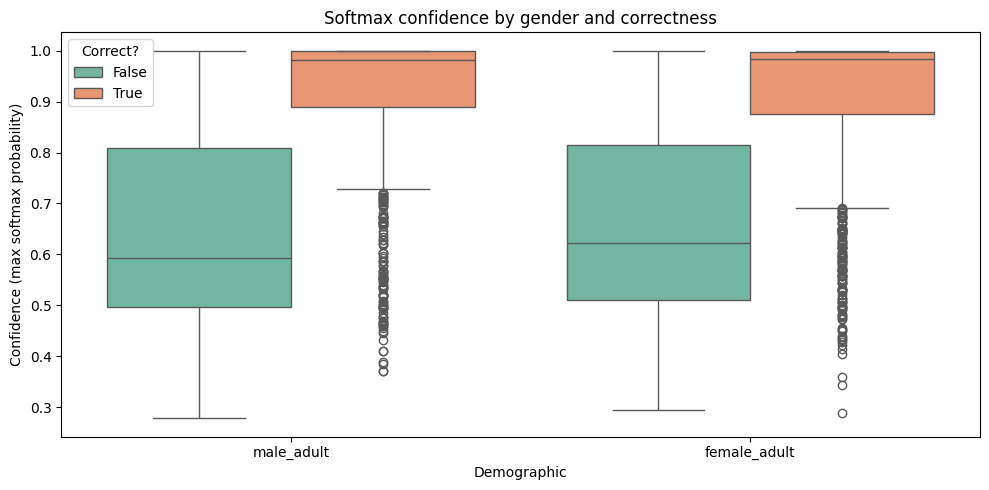

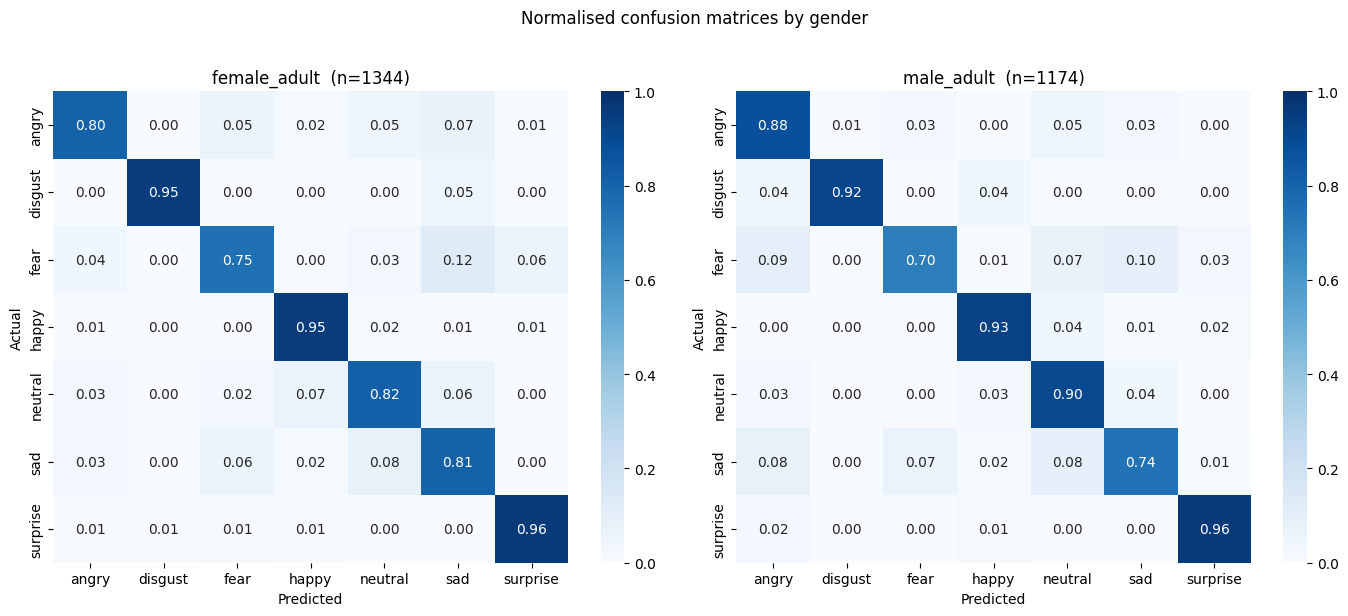

In [24]:
print("Analysis 3: Confidence Bias")

conf_summary = (df_results
                .groupby(["gender", "is_correct"])["confidence"]
                .agg(["mean", "median", "count"])
                .round(4))
print("\nConfidence by gender x correctness:")
print(conf_summary)

per_emotion_conf = (df_results
                    .groupby(["true_emotion", "gender"])["confidence"]
                    .mean()
                    .unstack("gender")
                    .round(4))
print("\nMean confidence per true emotion x gender:")
print(per_emotion_conf)

# Confidence box plots by gender
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_results, x="gender", y="confidence",
            hue="is_correct", palette="Set2")
plt.title("Softmax confidence by gender and correctness")
plt.xlabel("Demographic")
plt.ylabel("Confidence (max softmax probability)")
plt.legend(title="Correct?")
plt.tight_layout()
plt.show()

# Confusion matrix by gender
fig, axes = plt.subplots(1, len(genders), figsize=(7 * len(genders), 6))
if len(genders) == 1:
    axes = [axes]
for ax, g in zip(axes, genders):
    df_g = df_results[df_results["gender"] == g]
    cm   = confusion_matrix(df_g["true_emotion"], df_g["pred_emotion"],
                            labels=label_names)
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt=".2f",
                xticklabels=label_names, yticklabels=label_names,
                cmap="Blues", ax=ax, vmin=0, vmax=1)
    ax.set_title(f"{g}  (n={len(df_g)})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Normalised confusion matrices by gender", y=1.02)
plt.tight_layout()
plt.show()
